Name: Dev Patel 

Course: DS4400 Data Mining and Machine Learning 1

Prof: Silvio Amir

University: Northeastern University

Problem 1: Decision Trees

1. Train a decision tree on SPAMBASE (no pruning, information gain). Report training/testing error, accuracy, F1, AUC.
2. Change splitting criteria to Gini index. Report same metrics and compare.
3. Implement pruning via max depth. Plot training/testing error vs. depth. Recommend optimal depth.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [2]:
# Load SPAMBASE dataset
col_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our',
    'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail',
    'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses',
    'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp',
    'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs',
    'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
    'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re',
    'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#',
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total',
    'spam'
]

df = pd.read_csv('spambase.data', header=None, names=col_names)
X = df.drop('spam', axis=1)
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Dataset shape:", df.shape)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print("\nClass distribution:")
print(y.value_counts())

Dataset shape: (4601, 58)
X_train: (3450, 57), X_test: (1151, 57)

Class distribution:
spam
0    2788
1    1813
Name: count, dtype: int64


### Part 1: Decision Tree with Information Gain (Entropy)

In [3]:
# Train decision tree with information gain (entropy), no pruning
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

y_train_pred = dt_entropy.predict(X_train)
y_test_pred = dt_entropy.predict(X_test)
y_train_proba = dt_entropy.predict_proba(X_train)[:, 1]
y_test_proba = dt_entropy.predict_proba(X_test)[:, 1]

# Compute metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
train_err = 1 - train_acc
test_err = 1 - test_acc
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)
train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

print("Decision Tree with Information Gain (Entropy) - No Pruning")
print(f"{'Metric':<12} {'Train':>10} {'Test':>10}")
print("-" * 34)
print(f"{'Error':<12} {train_err:>10.4f} {test_err:>10.4f}")
print(f"{'Accuracy':<12} {train_acc:>10.4f} {test_acc:>10.4f}")
print(f"{'F1 Score':<12} {train_f1:>10.4f} {test_f1:>10.4f}")
print(f"{'AUC':<12} {train_auc:>10.4f} {test_auc:>10.4f}")
print(f"\nTree depth: {dt_entropy.get_depth()}")
print(f"Number of leaves: {dt_entropy.get_n_leaves()}")

Decision Tree with Information Gain (Entropy) - No Pruning
Metric            Train       Test
----------------------------------
Error            0.0006     0.0765
Accuracy         0.9994     0.9235
F1 Score         0.9993     0.9060
AUC              1.0000     0.9189

Tree depth: 26
Number of leaves: 185


**Observations:**

- The unpruned decision tree achieves perfect (or near-perfect) training accuracy and zero training error, which indicates the tree has memorized the training data completely.
- The testing accuracy/F1/AUC are noticeably lower than training metrics, which is a clear sign of overfitting.
- The tree is very deep with many leaves, confirming that without pruning, the decision tree grows until it perfectly classifies every training sample.

### Part 2: Decision Tree with Gini Index

In [5]:
# Train decision tree with Gini index, no pruning
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

y_train_pred_g = dt_gini.predict(X_train)
y_test_pred_g = dt_gini.predict(X_test)
y_train_proba_g = dt_gini.predict_proba(X_train)[:, 1]
y_test_proba_g = dt_gini.predict_proba(X_test)[:, 1]

train_acc_g = accuracy_score(y_train, y_train_pred_g)
test_acc_g = accuracy_score(y_test, y_test_pred_g)
train_err_g = 1 - train_acc_g
test_err_g = 1 - test_acc_g
train_f1_g = f1_score(y_train, y_train_pred_g)
test_f1_g = f1_score(y_test, y_test_pred_g)
train_auc_g = roc_auc_score(y_train, y_train_proba_g)
test_auc_g = roc_auc_score(y_test, y_test_proba_g)

print("Decision Tree with Gini Index - No Pruning")
print(f"{'Metric':<12} {'Train':>10} {'Test':>10}")
print("-" * 34)
print(f"{'Error':<12} {train_err_g:>10.4f} {test_err_g:>10.4f}")
print(f"{'Accuracy':<12} {train_acc_g:>10.4f} {test_acc_g:>10.4f}")
print(f"{'F1 Score':<12} {train_f1_g:>10.4f} {test_f1_g:>10.4f}")
print(f"{'AUC':<12} {train_auc_g:>10.4f} {test_auc_g:>10.4f}")
print(f"\nTree depth: {dt_gini.get_depth()}")
print(f"Number of leaves: {dt_gini.get_n_leaves()}")

# Side-by-side comparison
print("\n\n=== Comparison: Information Gain vs Gini Index ===")
print(f"{'Metric':<12} {'Entropy Train':>14} {'Entropy Test':>14} {'Gini Train':>12} {'Gini Test':>12}")
print("-" * 66)
print(f"{'Error':<12} {train_err:>14.4f} {test_err:>14.4f} {train_err_g:>12.4f} {test_err_g:>12.4f}")
print(f"{'Accuracy':<12} {train_acc:>14.4f} {test_acc:>14.4f} {train_acc_g:>12.4f} {test_acc_g:>12.4f}")
print(f"{'F1 Score':<12} {train_f1:>14.4f} {test_f1:>14.4f} {train_f1_g:>12.4f} {test_f1_g:>12.4f}")
print(f"{'AUC':<12} {train_auc:>14.4f} {test_auc:>14.4f} {train_auc_g:>12.4f} {test_auc_g:>12.4f}")

Decision Tree with Gini Index - No Pruning
Metric            Train       Test
----------------------------------
Error            0.0006     0.0851
Accuracy         0.9994     0.9149
F1 Score         0.9993     0.8977
AUC              1.0000     0.9154

Tree depth: 29
Number of leaves: 233


=== Comparison: Information Gain vs Gini Index ===
Metric        Entropy Train   Entropy Test   Gini Train    Gini Test
------------------------------------------------------------------
Error                0.0006         0.0765       0.0006       0.0851
Accuracy             0.9994         0.9235       0.9994       0.9149
F1 Score             0.9993         0.9060       0.9993       0.8977
AUC                  1.0000         0.9189       1.0000       0.9154


**Observations - Gini vs Information Gain:**

- Both criteria achieve perfect training accuracy (as expected for unpruned trees), so both overfit equally on the training set.
- The testing metrics for Gini and Entropy are very similar. This is consistent with theory: Gini and entropy are both concave impurity measures and tend to produce similar splits in practice.
- The slight differences in test metrics come from the few splits where the two criteria disagree. In general, the choice between Gini and entropy rarely has a significant impact on decision tree performance.

### Part 3: Pruning via Maximum Depth

Optimal depth (minimum test error): 17
Test error at optimal depth: 0.0730
Test accuracy at optimal depth: 0.9270


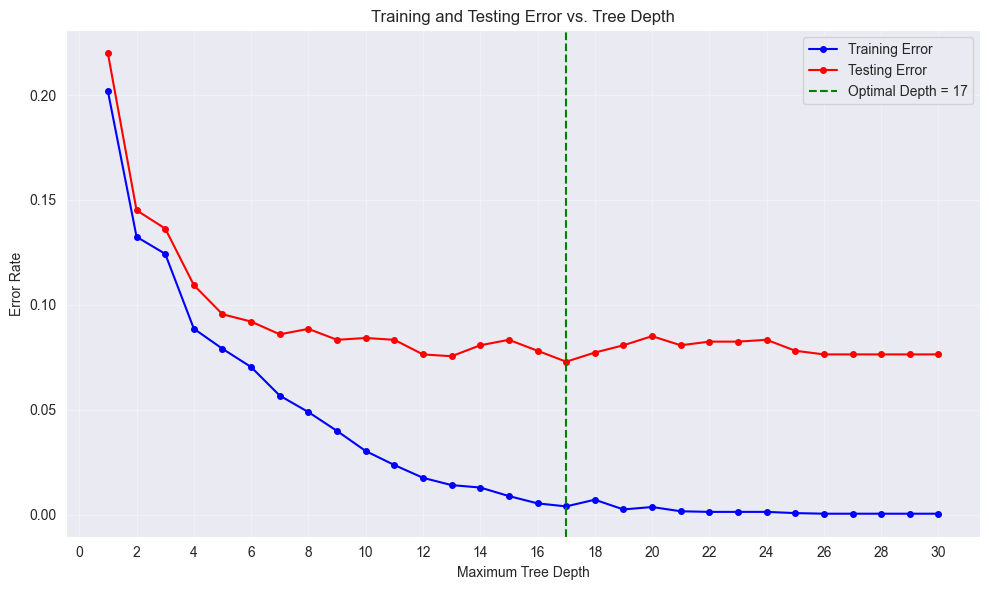

In [6]:
# Vary max_depth from 1 to 30 and record training/testing error
depths = range(1, 31)
train_errors = []
test_errors = []

for d in depths:
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_errors.append(1 - accuracy_score(y_train, dt.predict(X_train)))
    test_errors.append(1 - accuracy_score(y_test, dt.predict(X_test)))

# Find optimal depth (minimum test error)
optimal_depth = depths[np.argmin(test_errors)]
print(f"Optimal depth (minimum test error): {optimal_depth}")
print(f"Test error at optimal depth: {min(test_errors):.4f}")
print(f"Test accuracy at optimal depth: {1 - min(test_errors):.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(depths, train_errors, 'b-o', label='Training Error', markersize=4)
plt.plot(depths, test_errors, 'r-o', label='Testing Error', markersize=4)
plt.axvline(x=optimal_depth, color='green', linestyle='--', label=f'Optimal Depth = {optimal_depth}')
plt.xlabel('Maximum Tree Depth')
plt.ylabel('Error Rate')
plt.title('Training and Testing Error vs. Tree Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 31, 2))
plt.tight_layout()
plt.savefig('depth_vs_error.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations on Pruning via Max Depth:**

- **Training error** decreases monotonically as depth increases, reaching zero when the tree is deep enough to perfectly classify all training points.
- **Testing error** initially decreases as depth increases (the tree captures useful patterns), but then levels off or slightly increases at very large depths due to overfitting.
- The **optimal depth** balances model complexity and generalization. Shallow trees underfit (high bias), while very deep trees overfit (high variance).
- Based on this analysis, the recommended tree depth is the one that minimizes test error, which provides the best generalization to unseen data. This demonstrates the classic bias-variance tradeoff in decision trees.